<a href="https://colab.research.google.com/github/AbubakarMA/Abu/blob/main/Hosing_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [24]:
# Set seed for reproducibility
np.random.seed(42)

# Generate 100 houses
n = 100
Size = np.random.normal(2000, 500, n)        # Mean 2000 sq ft, SD 500
Bedrooms = np.random.randint(2, 6, n)        # 2 to 5 bedrooms
Age = np.random.randint(1, 50, n)            # 1 to 50 years old

# Generate price with some randomness
Price = 50 + 0.1*Size + 20*Bedrooms - 2*Age + np.random.normal(0, 25, n)


In [25]:
# Create DataFrame
df = pd.DataFrame({'Size': Size, 'Bedrooms': Bedrooms, 'Age': Age, 'Price': Price})

In [26]:
x = df[["Size", "Bedrooms", "Age"]]
y = df["Price"]

In [29]:
x = sm.add_constant(x)
model = sm.OLS(y,x).fit()

To simulate more data, I'll create some additional synthetic data points for 'Size', 'Bedrooms', 'Age', and 'Price'.

In [30]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     146.8
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           9.67e-36
Time:                        01:56:38   Log-Likelihood:                -471.85
No. Observations:                 100   AIC:                             951.7
Df Residuals:                      96   BIC:                             962.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.6588     16.097      2.464      0.0

In [31]:
# Example new house
new_house = pd.DataFrame({'const':[1],'Size':[2500],'Bedrooms':[4],'Age':[10]})

# Predict price
predicted_price = model.predict(new_house)
print(f"Predicted Price: ${predicted_price.iloc[0]:.2f}k")

Predicted Price: $356.33k


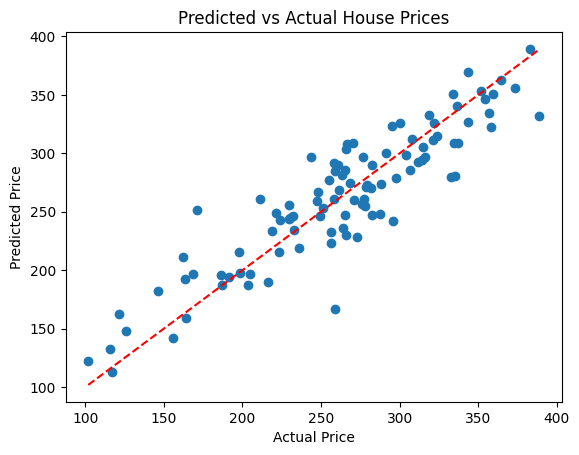

In [33]:
# Predicted prices for all houses
predicted = model.predict(x)

plt.scatter(y, predicted)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 45-degree line
plt.show()